# PyTorch Tutorial

In [1]:
# 2018-09-20 
# Install PyTorch
# conda install pytorch torchvision -c pytorch
# See https://pytorch.org/get-started/locally/
import torch
print(torch.__version__)

0.4.1


In [5]:
import torch
x = torch.empty(5, 3)
print(x)

tensor([[ 0.0000e+00,  3.6893e+19,  3.3828e-07],
        [ 1.5849e+29,  1.3304e+07,  4.5810e-41],
        [-3.1384e-07,         nan, -9.9290e+33],
        [ 5.0026e-43,  3.5480e+07,  4.5810e-41],
        [ 8.9683e-44, -2.5250e-29,  3.3751e-07]])


## PyTorch 101, Deep Learning PhD Course, 2017/2018, Marco Ciccone
https://marcociccone.github.io/assets/downloads/dl2018/%5BDL2018%5D%20PyTorch101.pdf

In [4]:
import torch
x = torch.Tensor(5, 3)
print(x)

tensor([[0.0000e+00, 3.6893e+19, 0.0000e+00],
        [3.6893e+19, 4.2981e+21, 6.3828e+28],
        [3.8016e-39, 0.0000e+00, 0.0000e+00],
        [3.6893e+19, 4.0619e-07, 2.5250e-29],
        [2.8131e+20, 1.7566e+25, 1.7748e+28]])


In [8]:
y = torch.rand(5, 3)
print(x + y) # Syntax 1A
print('---')
torch.add(x, y, out=result) # Syntax 1B
print(result)
print('---')
print(torch.add(x, y)) # Syntax 2
print('---')
y.add_(x) # In place
print(y)

tensor([[ 4.4365e-01,  3.6893e+19,  5.4761e-02],
        [ 1.5849e+29,  1.3304e+07,  7.2459e-01],
        [ 7.9349e-01,         nan, -9.9290e+33],
        [ 8.6130e-01,  3.5480e+07,  6.3737e-01],
        [ 5.0014e-01,  7.1492e-01,  8.2747e-01]])
---
tensor([[ 4.4365e-01,  3.6893e+19,  5.4761e-02],
        [ 1.5849e+29,  1.3304e+07,  7.2459e-01],
        [ 7.9349e-01,         nan, -9.9290e+33],
        [ 8.6130e-01,  3.5480e+07,  6.3737e-01],
        [ 5.0014e-01,  7.1492e-01,  8.2747e-01]])


In [9]:
# PyTorch => Numpy
import torch
a = torch.ones(5)
print(a)
b = a.numpy()
print(b)

tensor([1., 1., 1., 1., 1.])
[1. 1. 1. 1. 1.]


In [11]:
# Numpy => PyTorch
import torch
import numpy as np
a = np.ones(5)
b = torch.from_numpy(a)
np.add(a, 1, out=a)
print(a)
print(b)

[2. 2. 2. 2. 2.]
tensor([2., 2., 2., 2., 2.], dtype=torch.float64)


In [ ]:
# NOTE: The Torch Tensor and NumPy array will share their underlying memory locations,
# and changing one will change the other.

In [12]:
# CUDA Tensors
# let us run this cell only if CUDA is available
if torch.cuda.is_available():
    x = x.cuda()
    y = y.cuda()
    x + y
else:
    print('No CUDA')

No CUDA


In [ ]:
# Autograd (Automatic Differentiation)
# The autograd package provides automatic differentiation for all operations on Tensors. It is a define-by-run
# framework, which means that your backprop is defined by how your code is run, and that every single
# iteration can be different.

In [13]:
# Autograd Example
import torch
from torch.autograd import Variable

x = Variable(torch.ones(2, 2), requires_grad=True)
print(x)
y = x + 2
print(y)
print(y.grad_fn)
z = y * y * 3
out = z.mean()
print(z, out)
out.backward()
print(x.grad)

tensor([[1., 1.],
        [1., 1.]], requires_grad=True)
tensor([[3., 3.],
        [3., 3.]], grad_fn=<AddBackward>)
tensor([[27., 27.],
        [27., 27.]], grad_fn=<MulBackward>) tensor(27., grad_fn=<MeanBackward1>)
tensor([[4.5000, 4.5000],
        [4.5000, 4.5000]])


In [ ]:
# TODO Compléter les formules de 
# https://marcociccone.github.io/assets/downloads/dl2018/%5BDL2018%5D%20PyTorch101.pdf
# avec 
# http://www.math.harvard.edu/texman/node19.html#SECTION00082000000000000000

$$o=\frac{1}{4}\sum_{i}z_i$$
$$z_i=3(x_i+2)^2$$

In [14]:
# torch.nn package
# Neural network module.
# Convenient way of encapsulating parameters, with helpers for moving them to GPU,
# exporting, loading, etc…
model = torch.nn.Sequential(
    torch.nn.Linear(D_in, H),
    torch.nn.ReLU(),
    torch.nn.Linear(H, D_out),
)

NameError: name 'D_in' is not defined

In [15]:
# Custom module
import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel,
        # 6 output channels,
        # 5x5 square convolution kernel
        # nn.Conv2d will take in a 4D Tensor of nSamples x nChannels x Height x Width.
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)
        
    def forward(self, x):
        # Max pooling over a (2, 2) window
        x = F.max_pool2d(F.relu(self.conv1(x)), (2, 2))
        # If the size is a square, you can only specify a single number
        x = F.max_pool2d(F.relu(self.conv2(x)), 2)
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

    def num_flat_features(self, x):
        # all dimensions except the batch dimension
        size = x.size()[1:]
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [16]:
# The learnable parameters of a model are returned by net.parameters()
params = list(net.parameters())
print(len(params))
print(params[0].size()) # conv1's .weight

10
torch.Size([6, 1, 5, 5])


In [ ]:
# Mini-batches in torch.nn
# torch.nn only supports mini-batches
# The entire torch.nn package only supports inputs that are a mini-batch of samples, and not a
# single sample.
# For example, nn.Conv2d will take in a 4D Tensor of nSamples x nChannels x Height x Width.
# If you have a single sample, just use input.unsqueeze(0) to add a fake batch dimension.
# Ne comprends pas...

In [18]:
# Loss function
output = net(input)
target = Variable(torch.arange(1, 11)) # a dummy target, for example
criterion = nn.MSELoss()
loss = criterion(output, target)
print(loss)

TypeError: conv2d(): argument 'input' (position 1) must be Tensor, not method

In [17]:
# BackProp
# To backpropagate the error all we have to do is to loss.backward().
# You need to clear the existing gradients, otherwise gradients will be accumulated to existing gradients
# Now we shall call loss.backward(), and have a look at conv1’s bias gradients before and after the backward.
net.zero_grad() # zeroes the gradient buffers of all parameters
print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)
loss.backward()
print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None


NameError: name 'loss' is not defined

In [ ]:
# Optimizers
# However, as you use neural networks, you want to use various different update rules such as SGD, Nesterov-SGD, Adam,
# RMSProp, etc. To enable this, we built a small package: torch.optim that implements all these methods. Using it is very
# simple:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad() # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step() # Does the update

## Deep Learning with PyTorch: Object classification
https://perso.ensta-paristech.fr/~filliat/Courses/Polys/TP_DeepLearning.pdf

In [ ]:
# TODO

## MILA tutorials
https://github.com/mila-udem/welcome_tutorials/tree/master/pytorch


In [ ]:
# TODO

## Pytorch Tutorial, For Data Science HK, Given by Pranav A
https://datasciencehongkong.files.wordpress.com/2018/02/slides.pdf
https://github.com/pranav-ust/pytorch-tutorial

In [22]:
# Import libraries
from numpy import genfromtxt
import torch
import torch.nn as nn
import torchvision.datasets as dsets
import torchvision.transforms as transforms
from torch.autograd import Variable
import torch.utils.data as Data
import os

In [23]:
# Parameters and Hyper Parameters
input_size = 57
hidden_size1 = 64
hidden_size2 = 64
num_classes = 2
num_epochs = 256
batch_size = 128
learning_rate = 0.001

In [ ]:
# Load Data from CSVs
data = genfromtxt('traindata.csv', delimiter=',')
labels = genfromtxt('trainlabel.csv', delimiter=',')

input_data = data[:3000] # train
test_input = data[3000:] # test
output_data = labels[:3000] # train
test_output = labels[3000:] # test

In [ ]:
# Datasets
train_dataset = Data.TensorDataset(
    data_tensor = torch.from_numpy(input_data).float(),
    target_tensor = torch.from_numpy(output_data).long())

test_dataset = Data.TensorDataset(
    data_tensor = torch.from_numpy(test_input).float(),
    target_tensor = torch.from_numpy(test_output).long())

print(torch.from_numpy(output_data).int())

In [ ]:
# Data Loader (Input Pipeline)
train_loader = torch.utils.data.DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True)
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    shuffle=False)

In [ ]:
# Split dataset into Train & Test
# Make a dictionary defining training and validation sets
dataloders = dict()
dataloders['train'] = train_loader
dataloders['val'] = test_loader

dataset_sizes = {'train': 3000, 'val': 220}

In [ ]:
# Enable GPU
use_gpu = torch.cuda.is_available()

In [ ]:
# Net Structure
class Net(nn.Module):
    def __init__(self, input_size, hidden_size1, hidden_size2, num_classes):
        super(Net, self).__init__()
        self.fc1 = nn.Sequential(
            nn.Linear(input_size, hidden_size1),
            nn.ReLU())
        self.fc2 = nn.Sequential(
            nn.Linear(hidden_size1, hidden_size2),
            nn.ReLU())
        self.fc3 = nn.Sequential(
            nn.Linear(hidden_size2, num_classes))

    def forward(self, x):
        out = self.fc1(x)
        out = self.fc2(out)
        out = self.fc3(out)
        return out

In [ ]:
# Training Phase
def train_model(model, criterion, optimizer, num_epochs):
    f = open("Iterations.txt", "w+")
    best_model_wts = model.state_dict()
    best_val_acc = 0.0
    best_train_acc = 0.0
    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
		print('-' * 10)
		for phase in ['train', 'val']:
			if phase == 'train':
				model.train(True)  # Set model to training mode
			else:
				model.train(False)  # Set model to evaluate mode
			running_loss = 0.0
			running_corrects = 0
			# Iterate over data.
			for data in dataloders[phase]:
				# get the inputs
				inputs, label = data
				# wrap them in Variable
				if use_gpu:
					inputs = Variable(inputs.cuda())
					labels = Variable(label.cuda())
				else:
					inputs, labels = Variable(inputs), Variable(label)
				# zero the parameter gradients
				optimizer.zero_grad()
				# forward
				outputs = model(inputs)
				_, preds = torch.max(outputs.data, 1)
				loss = criterion(outputs, labels)
				# backward + optimize only if in training phase
				if phase == 'train':
					loss.backward()
					optimizer.step()
				# statistics
				running_loss += loss.data[0]
				running_corrects += torch.sum(preds == label)
			epoch_loss = running_loss / dataset_sizes[phase]
			epoch_acc = running_corrects / dataset_sizes[phase]
			#Print it out Loss and Accuracy and in the file torchvision
			print('{} Loss: {:.8f} Accuracy: {:.4f}'.format(phase, epoch_loss, epoch_acc))
			f.write('{} Loss: {:.8f} Accuracy: {:.4f}\n'.format(phase, epoch_loss, epoch_acc))
			# deep copy the model
			if phase == 'val' and epoch_acc > best_val_acc:
				best_val_acc = epoch_acc
				best_model_wts = model.state_dict()
			if phase == 'train' and epoch_acc > best_train_acc:
				best_train_acc = epoch_acc
				best_model_wts = model.state_dict()
	f.close()
	print('Best val Acc: {:4f}'.format(best_val_acc))
	model.load_state_dict(best_model_wts)
	return model, best_train_acc, best_val_acc

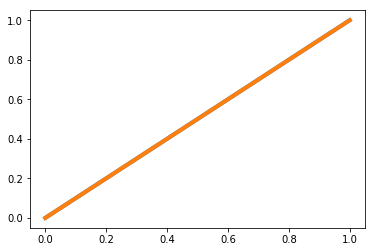

In [24]:
%matplotlib inline
import matplotlib.pyplot as plt
plt.plot([[0, 0], [1, 1]], linewidth=4, label="random diagonal")
plt.show()

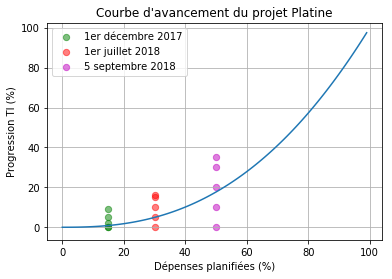

In [57]:
import matplotlib.pyplot as plt
import numpy as np

x = np.arange(0.0, 100.0, 1.0)
y = np.power(x, 2.5)/1000
plt.plot(x, y)

x = (15, 15, 15, 15, 15)
y = ( 0, 0, 2, 5, 9)
plt.scatter(x, y, s=40, c="g", alpha=0.5, label="1er décembre 2017")

x = (30, 30, 30, 30, 30)
y = ( 0, 5, 10, 15, 16)
plt.scatter(x, y, s=40, c="r", alpha=0.5, label="1er juillet 2018")

x = (50, 50, 50, 50, 50)
y = ( 0, 10, 20, 30, 35)
plt.scatter(x, y, s=40, c="m", alpha=0.5, label="5 septembre 2018")

plt.title("Courbe d'avancement du projet Platine")
plt.xlabel("Dépenses planifiées (%)")
plt.ylabel("Progression TI (%)")
plt.legend(loc=2)
plt.grid(True)
plt.savefig("courbe.png")
plt.show()